# **Pertpy-GPU**

**Accelerated Perturbation Distance Analysis**  

**Authors:** [Lukas Heumos](https://github.com/zethson), [Severin Dicks](https://github.com/Intron7)
**Copyright** [scverse](https://scverse.org)

Here, we explore GPU-accelerated perturbation distance computations using **rapids-singlecell**'s `rsc.ptg` module, which mirrors the API of [pertpy](https://pertpy.readthedocs.io)'s `Distance` class.

By running these analyses on GPUs, we can scale to large perturbation screens (many groups, many cells) where pairwise distance computation would otherwise be a bottleneck.
We use the **E-distance** (energy distance) to quantify how strongly each perturbation shifts the cell-state distribution relative to controls.

In [1]:
import rapids_singlecell as rsc
import anndata as ad
import pertpy as pt
import seaborn as sns
import matplotlib.pyplot as plt

## Load Example Data

We use the `distance_example` dataset of pertpy — a small, preprocessed subset of the Perturb-seq data from [Dixit et al., 2016](https://doi.org/10.1016/j.cell.2016.11.038) — which contains a `perturbation` annotation in `.obs` and a PCA embedding in `.obsm["X_pca"]`.

In [2]:
adata = pt.dt.distance_example()
adata

AnnData object with n_obs × n_vars = 3200 × 2000
    obs: 'perturbation', 'grna_lenient', 'target', 'moi', 'cell_line', 'celltype', 'perturbation_type', 'cancer', 'disease', 'guide_id', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'n_counts'
    var: 'gene_id', 'mt', 'ribo', 'ncounts', 'ncells', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

## Prepare for distance metrics

Distance metrics are computed in PCA space to avoid the curse of dimensionality.

In [3]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.pca(adata, n_comps=50)

## Pairwise E-distances

The `Distance` class computes pairwise distances between all groups defined by a column in `.obs`.
By default it reads the embedding from `.obsm["X_pca"]`.

In [4]:
%%time
distance = rsc.ptg.Distance(metric="edistance", obsm_key="X_pca")
df = distance.pairwise(adata, groupby="perturbation")
df.head()

CPU times: user 34.2 ms, sys: 88.9 ms, total: 123 ms
Wall time: 140 ms


perturbation,control,p-INTERGENIC216151,p-INTERGENIC393453,p-INTERGENIC393453_p-sgELF1-2,p-INTERGENIC1144056,p-INTERGENIC1216445,p-sgCREB1-2,p-sgCREB1-4,p-sgCREB1-5,p-sgE2F4-6,...,p-sgETS1-5,p-sgGABPA-1,p-sgGABPA-9,p-sgIRF1-2,p-sgIRF1-3,p-sgNR2C2-2,p-sgNR2C2-3,p-sgNR2C2-5,p-sgYY1-3,p-sgYY1-10
perturbation,,,,,,,,,,,,,,,,,,,,,
control,0.000000,0.186348,0.221331,0.271880,0.262410,0.259739,0.252042,0.388346,0.255588,0.305329,...,11.117786,11.345467,10.817892,10.989595,10.938345,10.762506,10.968601,11.135164,10.956791,11.002567
p-INTERGENIC216151,0.186348,0.000000,-0.004433,0.029946,-0.004575,-0.007889,0.033900,0.007107,-0.023688,-0.010982,...,10.886147,11.144894,10.528135,10.766272,10.794701,10.597757,10.688713,10.957037,10.697678,10.740091
p-INTERGENIC393453,0.221331,-0.004433,0.000000,-0.011823,0.014314,0.090172,0.001603,0.047546,0.031596,-0.002492,...,10.911249,11.148912,10.549551,10.722809,10.763332,10.516935,10.690411,10.937792,10.667976,10.665668
p-INTERGENIC393453_p-sgELF1-2,0.271880,0.029946,-0.011823,0.000000,0.037041,0.076026,0.072382,0.057895,0.060162,-0.025307,...,10.918885,11.118722,10.542020,10.687470,10.792460,10.574527,10.676620,10.971744,10.721988,10.744924
p-INTERGENIC1144056,0.262410,-0.004575,0.014314,0.037041,0.000000,0.050689,0.090553,0.043807,0.030745,-0.004827,...,10.845412,11.141158,10.521075,10.756488,10.758624,10.565110,10.643741,10.930161,10.650750,10.681153


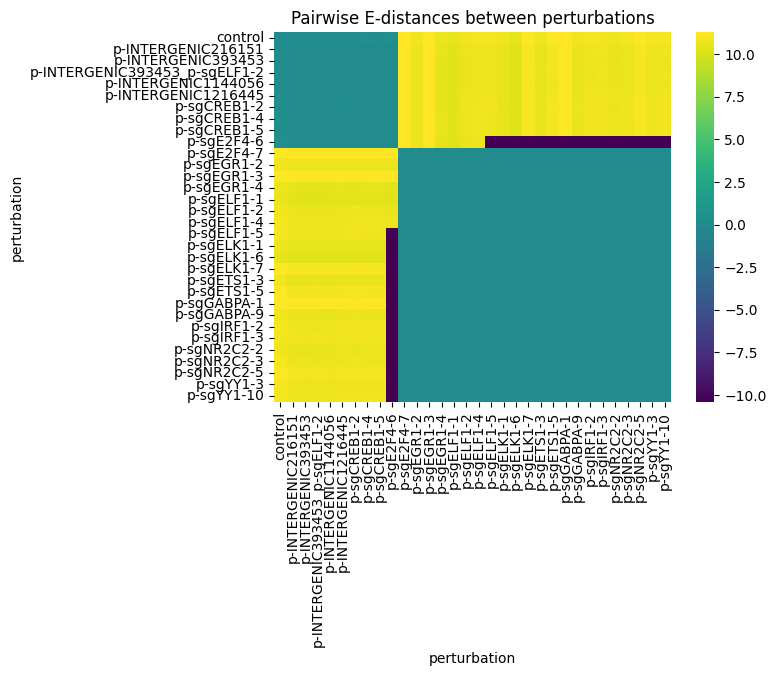

In [5]:
sns.heatmap(df, robust=True, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Pairwise E-distances between perturbations")
plt.show()

## Contrast Against a Baseline

A common perturbation-screen question is *"how strongly does each perturbation shift cells away from the unperturbed baseline?"*.
We answer this with `Distance.create_contrasts` (which builds a tidy contrasts table — one row per `(target, reference)` pair) and `Distance.contrast_distances` (which fills in the distance for each contrast).
This is more flexible than the raw pairwise matrix: you can pass multiple references, restrict to a subset of targets, or stratify by another `.obs` column (e.g. cell type) via `split_by`.

In [6]:
%%time
contrasts = rsc.ptg.Distance.create_contrasts(
    adata, groupby="perturbation", selected_group="control"
)
result = distance.contrast_distances(adata, contrasts=contrasts)
result.sort_values("edistance", ascending=False).head(10)

CPU times: user 5.82 ms, sys: 0 ns, total: 5.82 ms
Wall time: 5.43 ms


,perturbation,reference,edistance
6,p-sgCREB1-4,control,0.388346
8,p-sgE2F4-6,control,0.305329
14,p-sgELF1-2,control,0.284894
4,p-INTERGENIC393453_p-sgELF1-2,control,0.271880
0,p-INTERGENIC1144056,control,0.262410
1,p-INTERGENIC1216445,control,0.259739
13,p-sgELF1-1,control,0.256044
7,p-sgCREB1-5,control,0.255588
5,p-sgCREB1-2,control,0.252042
12,p-sgEGR1-4,control,0.231539


## Bootstrap Variance Estimation

Setting `bootstrap=True` returns both the distance estimates and a per-pair variance, computed by resampling cells.
Unlike pertpy's CPU implementation, the GPU version recomputes distances each iteration rather than precomputing an n×n cell-distance matrix, so memory scales linearly in the number of cells.

In [7]:
%%time
df_mean, df_var = distance.pairwise(
    adata, groupby="perturbation", bootstrap=True, n_bootstrap=50, random_state=0
)
df_var.head()

CPU times: user 198 ms, sys: 36 ms, total: 234 ms
Wall time: 233 ms


perturbation,control,p-INTERGENIC216151,p-INTERGENIC393453,p-INTERGENIC393453_p-sgELF1-2,p-INTERGENIC1144056,p-INTERGENIC1216445,p-sgCREB1-2,p-sgCREB1-4,p-sgCREB1-5,p-sgE2F4-6,...,p-sgETS1-5,p-sgGABPA-1,p-sgGABPA-9,p-sgIRF1-2,p-sgIRF1-3,p-sgNR2C2-2,p-sgNR2C2-3,p-sgNR2C2-5,p-sgYY1-3,p-sgYY1-10
perturbation,,,,,,,,,,,,,,,,,,,,,
control,0.000000,0.615649,0.676248,0.707371,0.690252,0.755486,0.730110,0.638013,0.613150,0.629978,...,0.492958,0.507647,0.545649,0.510374,0.527144,0.538761,0.512155,0.527787,0.539033,0.561692
p-INTERGENIC216151,0.615649,0.000000,0.620489,0.845119,0.677616,0.606445,0.695760,0.449387,0.503359,0.487891,...,0.372297,0.412535,0.424212,0.457976,0.380719,0.561012,0.367475,0.583241,0.481966,0.469871
p-INTERGENIC393453,0.676248,0.620489,0.000000,0.729666,0.739730,0.572041,0.667218,0.475155,0.465109,0.439003,...,0.378681,0.478793,0.450716,0.400178,0.476515,0.455279,0.392606,0.477264,0.418814,0.487899
p-INTERGENIC393453_p-sgELF1-2,0.707371,0.845119,0.729666,0.000000,0.940516,0.728477,0.796336,0.615655,0.631689,0.575075,...,0.507098,0.495822,0.604118,0.634317,0.585327,0.621911,0.548687,0.698822,0.528945,0.545236
p-INTERGENIC1144056,0.690252,0.677616,0.739730,0.940516,0.000000,0.739009,0.698736,0.606369,0.644801,0.539035,...,0.463750,0.559078,0.561818,0.606893,0.667035,0.612539,0.575785,0.593551,0.513972,0.595869
